In [2]:
import pandas as pd
df=pd.read_csv("cookie_cats.csv.zip")
print(df.shape)
df.head()

(90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
#check for duplicate users
print("Duplicate users:",df['userid'].duplicated().sum())

#check group sizes
print(df['version'].value_counts())

#check for missing values
print(df.isnull().sum())

#check the range of sum_gamerounds
print(df['sum_gamerounds'].describe())

Duplicate users: 0
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64
count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64


In [6]:
#Raw retention rates(sanity check)
retention_summary=df.groupby('version')[['retention_1','retention_7']].mean()
print(retention_summary)

         retention_1  retention_7
version                          
gate_30     0.448188     0.190201
gate_40     0.442283     0.182000


In [23]:
#two proportion Z-test
from statsmodels.stats.proportion import proportions_ztest
group_a=df[df['version']=='gate_30']
group_b=df[df['version']=='gate_40']
successes=[group_a['retention_1'].sum(),group_b['retention_1'].sum()]
n_obs=[len(group_a),len(group_b)]
z_stat,p_value=proportions_ztest(successes,n_obs)
print(f"Zstat:{z_stat:.4f},P-value:{p_value:4f}")

successes=[group_a['retention_7'].sum(),group_b['retention_7'].sum()]
n_obs=[len(group_a),len(group_b)]
z_stat,p_value=proportions_ztest(successes,n_obs)
print(f"Zstat:{z_stat:.4f},P-value:{p_value:4f}")



Zstat:1.7841,P-value:0.074410
Zstat:3.1644,P-value:0.001554


In [13]:
#confidence intervels
from statsmodels.stats.proportion import proportion_confint
for name,group in [('gate_30',group_a),('gate_40',group_b)]:
  ci_low,ci_high=proportion_confint(group['retention_1'].sum(),len(group),alpha=0.05)
  print(f"{name} retention_1 95% CI:[{ci_low:4f},{ci_high:4f}]")

gate_30 retention_1 95% CI:[0.443578,0.452798]
gate_40 retention_1 95% CI:[0.437719,0.446847]


In [14]:
import numpy as np
boot_diffs=[]
for _ in range(10000):
  sample_a=group_a['retention_1'].sample(frac=1,replace=True)
  sample_b=group_b['retention_1'].sample(frac=1,replace=True)
  boot_diffs.append(sample_a.mean()-sample_b.mean())
boot_diffs=np.array(boot_diffs)
print(f"Bootstrap mean diff:{boot_diffs.mean():.4f}")
print(f"95% CI:[{np.percentile(boot_diffs,2.5):.4f},{np.percentile(boot_diffs,97.5):.4f}]")


Bootstrap mean diff:0.0059
95% CI:[-0.0007,0.0123]


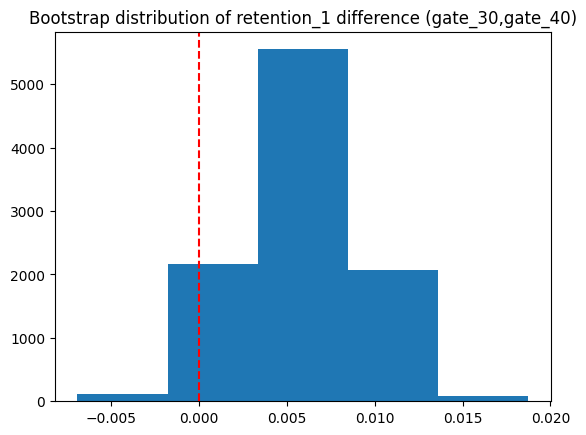

In [16]:
import matplotlib.pyplot as plt
plt.hist(boot_diffs,bins=5)
plt.axvline(0,color='red',linestyle='--')
plt.title('Bootstrap distribution of retention_1 difference (gate_30,gate_40)')
plt.show()

In [18]:
#power analysis
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
p1=group_a['retention_1'].mean()
p2=group_b['retention_1'].mean()
effect_size=proportion_effectsize(p1,p2)
analysis=NormalIndPower()
required_n=analysis.solve_power(effect_size=effect_size,alpha=0.05,power=0.8,alternative='two-sided')
print(f"Required sample size per group:{required_n:.0f}")
print(f"Actual sample size per group:{len(group_a)},{len(group_b)}")


Required sample size per group:111190
Actual sample size per group:44700,45489


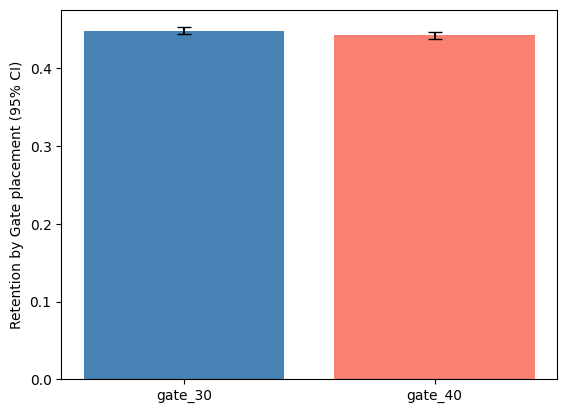

In [19]:
#final visualization
means=[p1,p2]
errors=[1.96*np.sqrt(p1*(1-p1)/len(group_a)),1.96*np.sqrt(p2*(1-p2)/len(group_b))]
plt.bar(['gate_30','gate_40'],means,yerr=errors,capsize=5,color=['steelblue','salmon'])
plt.ylabel('Retention by Gate placement (95% CI)')
plt.savefig('retention_comparison.png',dpi=150)
plt.show()

##Key findings

Day-1 retention shows no statistically significant difference between gate_30 and gate_40 (p=0.074).

Day-7 retention shows a statistically significant difference (p=0.0016),with gate_30 retaining more players than gate_40.

##Recommendation

Keep the first gate at level 30.Moving it to level 40 does not improve short-term engagement and signuficantly reduces 7-day retention.